# Ch18 運動控制中的觀測器(Using the Luenberger Observer in Motion Control)

**對應原書**:Chapter 18
**軟體替代**:ModelQ 觀測器範例 → 觀測器速度回授 vs 編碼器差分回授的迴路級對決

## 學習目標
1. 把第 10 章的觀測器放進**閉迴路**:速度回授改用 $\hat{\omega}$。
2. 量化效益:同樣增益下**轉矩雜訊降一個數量級以上**。
3. 理解為什麼觀測器優於低通:用「模型 + 轉矩命令」預測,**不用等量測** —— 沒有濾波器的相位代價。

## 架構
```
        ┌──────────── DiscretePID ◄─── ŵ ────────────┐
        u(轉矩命令)                          Luenberger 觀測器
        ├──────────────► 馬達 ──► 編碼器(量化位置)──┤
        └──────────────────────────────────────────►(u 也餵給觀測器)
```

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

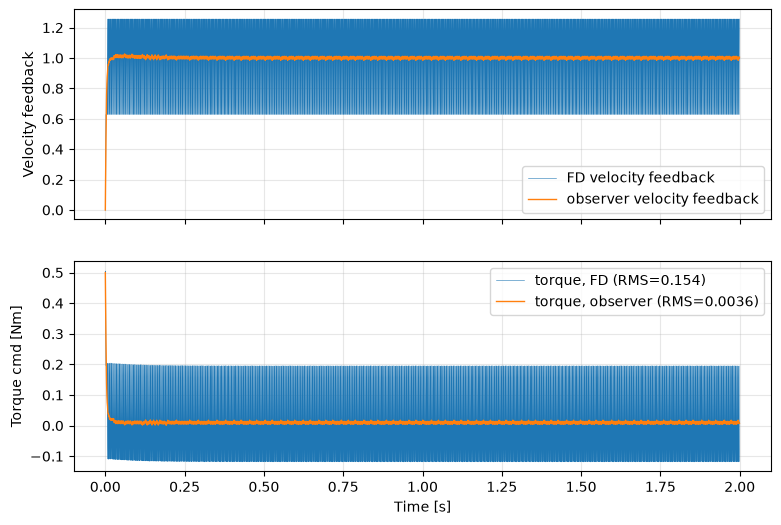

kp=0.5:轉矩雜訊 RMS 差分 0.1536 → 觀測器 0.0036(改善 43 倍)


In [2]:
J, b = 0.002, 0.01
fs = 1000.0
dt = 1 / fs
n = int(2.0 / dt)
t = np.arange(n) * dt

A = np.array([[0.0, 1.0], [0.0, -b / J]])
B = np.array([[0.0], [1.0 / J]])
Cm = np.array([[1.0, 0.0]])
L = np.asarray(ct.place(A.T, Cm.T, [-200, -220])).T
enc = EncoderModel(lines=2500)
q_rad = 2 * np.pi / enc.counts_per_rev

def vel_loop(feedback, kp, ki=5.0):
    """feedback: 'fd'(編碼器差分)或 'obs'(觀測器)。"""
    plant = MotorPlant(J=J, b=b, dt=dt)
    c = DiscretePID(kp, ki, dt=dt)
    xhat = np.zeros(2)
    prev_y, u_prev = 0.0, 0.0
    u_log, w_log, fb_log = np.empty(n), np.empty(n), np.empty(n)
    for k in range(n):
        w_log[k] = plant.w
        y = float(enc.read(plant.pos / (2 * np.pi))) * 2 * np.pi
        w_fd = (y - prev_y) / dt
        prev_y = y
        innov = y - (Cm @ xhat)[0]
        xhat = xhat + (A @ xhat + B.ravel() * u_prev + L.ravel() * innov) * dt
        fb = w_fd if feedback == 'fd' else xhat[1]
        fb_log[k] = fb
        u = c.step(1.0 - fb)
        u_log[k] = u_prev = u
        plant.step(u)
    return u_log, w_log, fb_log

kp0 = 0.5
u_fd, w_fd_loop, fb_fd = vel_loop('fd', kp0)
u_ob, w_ob_loop, fb_ob = vel_loop('obs', kp0)
settle = slice(int(1.0 / dt), n)
rms_fd = float(np.std(u_fd[settle]))
rms_ob = float(np.std(u_ob[settle]))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax1.plot(t, fb_fd, lw=0.4, label='FD velocity feedback')
ax1.plot(t, fb_ob, lw=1.0, label='observer velocity feedback')
ax1.set_ylabel('Velocity feedback'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(t, u_fd, lw=0.4, label=f'torque, FD (RMS={rms_fd:.3f})')
ax2.plot(t, u_ob, lw=1.0, label=f'torque, observer (RMS={rms_ob:.4f})')
ax2.set_ylabel('Torque cmd [Nm]'); ax2.set_xlabel('Time [s]'); ax2.legend(); ax2.grid(alpha=0.3)
plt.show()
print(f'kp={kp0}:轉矩雜訊 RMS 差分 {rms_fd:.4f} → 觀測器 {rms_ob:.4f}(改善 {rms_fd/rms_ob:.0f} 倍)')

## 觀測器讓你「買得起」更高的增益

差分回授下,轉矩雜訊 RMS ≈ $k_p \cdot q/(\sqrt{6}T_s)$ —— 增益越高雜訊越炸(馬達發熱、聽得到嘶聲)。
觀測器把這條雜訊稅撤掉,同一顆編碼器能撐起更高的迴路增益。

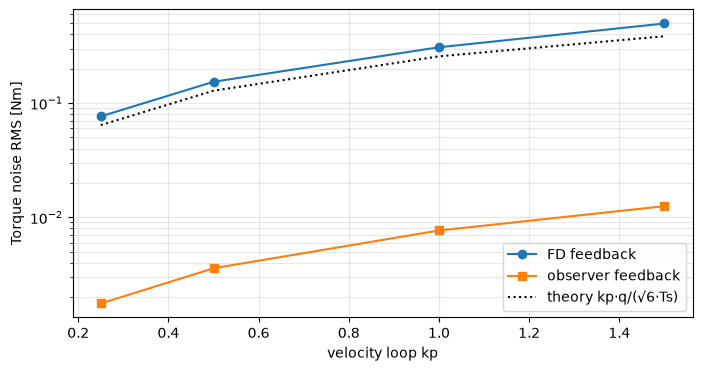

    kp        FD  observer   ratio
  0.25    0.0764    0.0018    43.5
   0.5    0.1536    0.0036    43.0
   1.0    0.3080    0.0077    40.2
   1.5    0.4975    0.0125    39.8


In [3]:
kps = [0.25, 0.5, 1.0, 1.5]
noise_fd, noise_ob = [], []
for kp in kps:
    uf, _, _ = vel_loop('fd', kp)
    uo, _, _ = vel_loop('obs', kp)
    noise_fd.append(float(np.std(uf[settle])))
    noise_ob.append(float(np.std(uo[settle])))

plt.figure(figsize=(8, 4))
plt.semilogy(kps, noise_fd, 'o-', label='FD feedback')
plt.semilogy(kps, noise_ob, 's-', label='observer feedback')
theory = [kp * q_rad / np.sqrt(6) / dt for kp in kps]
plt.semilogy(kps, theory, 'k:', label='theory kp·q/(√6·Ts)')
plt.xlabel('velocity loop kp'); plt.ylabel('Torque noise RMS [Nm]')
plt.legend(); plt.grid(alpha=0.3, which='both')
plt.show()
print(f"{'kp':>6} {'FD':>9} {'observer':>9} {'ratio':>7}")
for kp, nf, no in zip(kps, noise_fd, noise_ob):
    print(f'{kp:>6} {nf:>9.4f} {no:>9.4f} {nf/no:>7.1f}')

In [4]:
# ✅ 驗證
assert rms_ob < rms_fd / 10                         # 至少一個數量級
assert abs(float(np.mean(w_ob_loop[settle])) - 1.0) < 0.01   # 追蹤沒有犧牲
assert abs(float(np.mean(w_fd_loop[settle])) - 1.0) < 0.02   # (平均;瞬時值受雜訊擾動)
for nf, no in zip(noise_fd, noise_ob):
    assert no < nf / 5
# FD 雜訊與理論公式同量級
for kp, nf in zip(kps, noise_fd):
    th = kp * q_rad / np.sqrt(6) / dt
    assert 0.3 < nf / th < 3
print('Ch18 驗證通過 ✅')

Ch18 驗證通過 ✅


## 練習
1. 觀測器模型的 J 故意錯 +30%,轉矩雜訊與追蹤性能各受多少影響?(觀測器的魯棒性)
2. 把觀測器極點加快 5 倍,雜訊變大還是變小?收斂變快還是變慢?畫出取捨曲線。
3. 對比「FD + 200 Hz 低通」與觀測器:step response 的相位差多少?(低通的代價)
4. 負載轉矩擾動下(第 7 章),觀測器回授的迴路擾動響應有沒有變差?為什麼幾乎沒有?